In [1]:
#Step 0: Load libraries and custom models
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, r2_score
from sklearn.datasets import load_iris

In [2]:
#Step 1: Load data
X_raw, y_raw = load_iris(return_X_y=True, as_frame=True)
df_raw = X_raw
df_raw['species'] = y_raw
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [3]:
df_raw.sample(10, random_state=2025)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
2,4.7,3.2,1.3,0.2,0
148,6.2,3.4,5.4,2.3,2
112,6.8,3.0,5.5,2.1,2
132,6.4,2.8,5.6,2.2,2
0,5.1,3.5,1.4,0.2,0
113,5.7,2.5,5.0,2.0,2
34,4.9,3.1,1.5,0.2,0
51,6.4,3.2,4.5,1.5,1
135,7.7,3.0,6.1,2.3,2
5,5.4,3.9,1.7,0.4,0


In [4]:
#Step 2: Preprocessing

df_baking = df_raw.copy()
df_baking.columns = df_baking.columns.str.replace(' ', '_')
df_baking['species'] = df_baking['species'].map({
    0:'setosa',
    1:'versicolor',
    2:'virginica'
    })
df_baking['species'] = df_baking['species'].astype('category')
df = df_baking.copy()
df

,sepal_length_(cm),sepal_width_(cm),petal_length_(cm),petal_width_(cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [5]:
#Step 3: EDA

df_train, df_test = train_test_split(
                                     df,
                                     test_size=0.2, 
                                     random_state=2025,
                                     stratify=df['species'] 
                                     )
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.shape, df_test.shape

((120, 5), (30, 5))

In [6]:
display(df_train.describe(include='number').T)
display(df_train.describe(include='category').T)

,count,mean,std,min,25%,50%,75%,max
sepal_length_(cm),120.0,5.830000,0.814119,4.3,5.100,5.8,6.4,7.9
sepal_width_(cm),120.0,3.054167,0.436159,2.0,2.800,3.0,3.4,4.4
petal_length_(cm),120.0,3.753333,1.766016,1.1,1.575,4.4,5.1,6.9
petal_width_(cm),120.0,1.203333,0.760355,0.1,0.300,1.3,1.8,2.5


,count,unique,top,freq
species,120,3,setosa,40


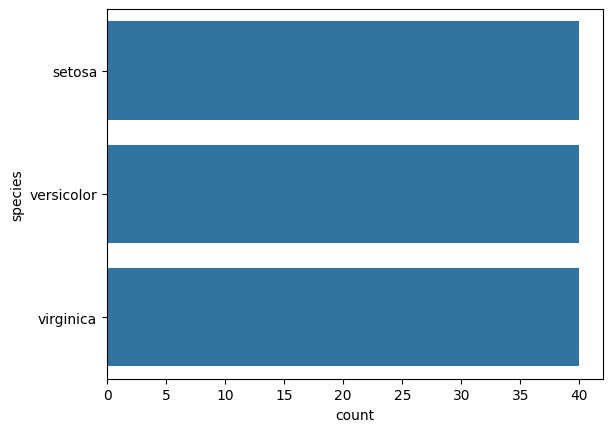

In [7]:
sns.countplot(df_train, y='species')
plt.show()

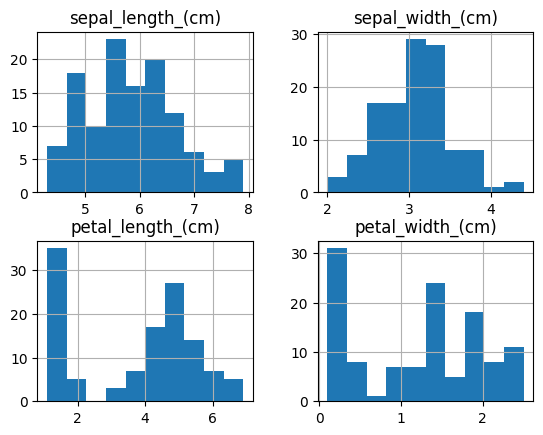

In [8]:
df_train.hist()
plt.show()

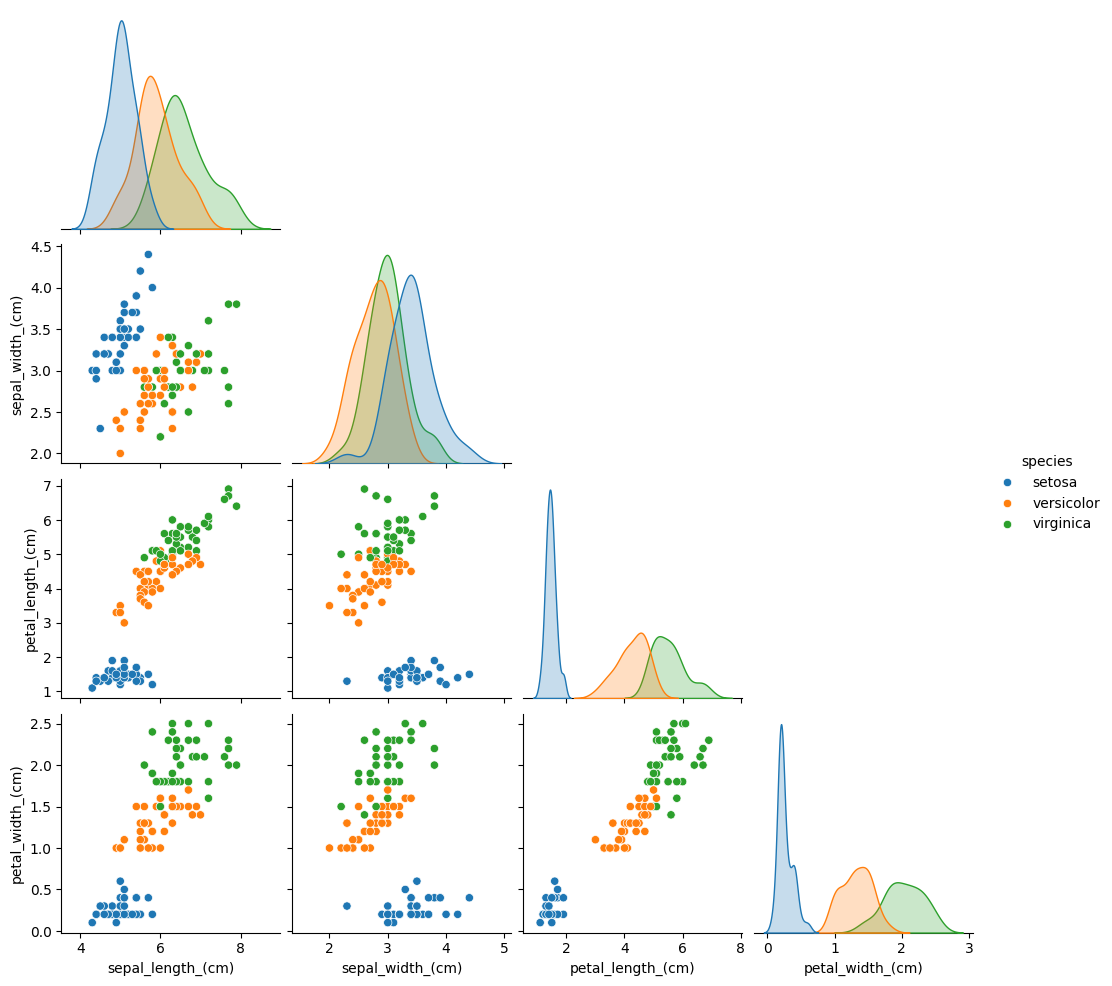

In [9]:
sns.pairplot(df_train, hue='species', corner=True)
plt.show()

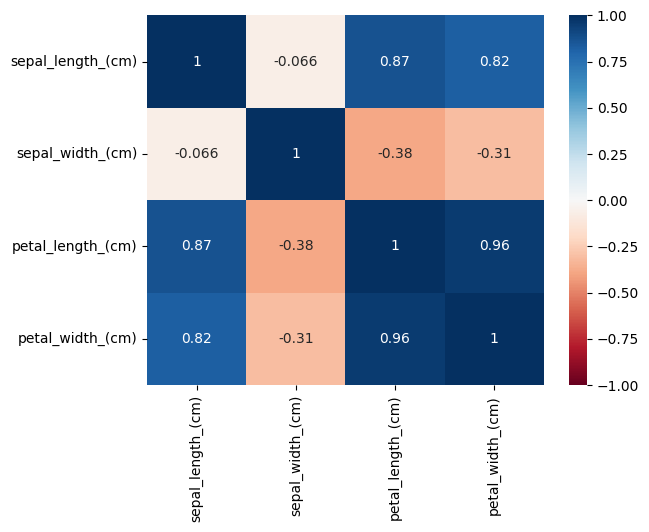

In [10]:
sns.heatmap(df_train.select_dtypes('number').corr(), vmin=-1, vmax=1, annot=True, cmap='RdBu')
plt.show()

In [11]:
#Step 4: Machine Learning (Random forest)

X_train = df_train.drop(columns='species')
y_train = df_train['species']

X_test = df_test.drop(columns='species')
y_test = df_test['species']

In [12]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)



In [13]:
clf_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=2025))
])

In [14]:
clf_rf.fit(X_train, y_train_enc)
y_hat = clf_rf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test_enc, y_hat):.2f}, R2 score: {r2_score(y_test_enc, y_hat):.2f}')

Accuracy: 0.97, R2 score: 0.95


In [15]:
#Step 5: Packing model

artifact = {
    'name':'prediction model for iris classification dataset',
    'author':'Addán Isaí Cruz Cruz',
    'model':clf_rf, 
    'predictors':X_train.columns.tolist(),
    'target_name':y_train.name,
    'version':'1.0',
    'algorithm_name':'Random forest',
    'encoder_target_values':label_encoder
}

In [16]:
df_predict = pd.DataFrame([[4.7,3.2,1.3,0.2]], columns=artifact["predictors"])
artifact['model'].predict(df_predict)

array([0])

In [17]:
with open('../models/iris_model.pkl', 'wb') as file:
    pickle.dump(artifact, file)